# Used-Car Pricing & Depreciation Analysis
### Evidence from 762,000 U.S. Vehicle Listings

## Project Overview

This project examines how selected vehicle characteristics are associated with used-car listing prices in the United States.

The analysis focuses on two business questions:

1. How is reported accident or damage history associated with vehicle listing price?
2. How is reported one-owner status associated with vehicle listing price?

The project uses descriptive analysis, regression modeling, model/trim fixed effects, and robustness checks to separate raw price differences from differences that may be related to other vehicle characteristics.

Because the data is observational, the results are interpreted as associations rather than causal effects.

## Dataset and Time Period

The dataset contains **762,091 U.S. used-vehicle listings collected in April 2023**.

Therefore, the analysis represents listing conditions observed during that period and should not be interpreted as describing the current used-car market.

Prices represent vehicle **listing prices rather than final transaction prices**. Market conditions, vehicle values, consumer preferences, and the composition of used-vehicle inventory may have changed since the data was collected.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [38]:
cars = pd.read_csv("cars.csv")

print("Dataset shape:", cars.shape)

cars.head()

Dataset shape: (762091, 20)


,manufacturer,model,year,mileage,engine,transmission,drivetrain,fuel_type,mpg,exterior_color,interior_color,accidents_or_damage,one_owner,personal_use_only,seller_name,seller_rating,driver_rating,driver_reviews_num,price_drop,price
0,Acura,ILX Hybrid 1.5L,2013,92945.0,"1.5L I-4 i-VTEC variable valve control, engine...",Automatic,Front-wheel Drive,Gasoline,39-38,Black,Parchment,0.0,0.0,0.0,Iconic Coach,NaN,4.4,12.0,300.0,13988.0
1,Acura,ILX Hybrid 1.5L,2013,47645.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Gray,Ebony,1.0,1.0,1.0,Kars Today,NaN,4.4,12.0,NaN,17995.0
2,Acura,ILX Hybrid 1.5L,2013,53422.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Bellanova White Pearl,Ebony,0.0,1.0,1.0,Weiss Toyota of South County,4.3,4.4,12.0,500.0,17000.0
3,Acura,ILX Hybrid 1.5L,2013,117598.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,Polished Metal Metallic,NaN,0.0,1.0,1.0,Apple Tree Acura,NaN,4.4,12.0,675.0,14958.0
4,Acura,ILX Hybrid 1.5L,2013,114865.0,1.5L I4 8V MPFI SOHC Hybrid,Automatic CVT,Front-wheel Drive,Hybrid,39-38,NaN,Ebony,1.0,0.0,1.0,Herb Connolly Chevrolet,3.7,4.4,12.0,300.0,14498.0


In [39]:
print("Columns:")
print(cars.columns.tolist())

print("\nData types:")
print(cars.dtypes)

Columns:
['manufacturer', 'model', 'year', 'mileage', 'engine', 'transmission', 'drivetrain', 'fuel_type', 'mpg', 'exterior_color', 'interior_color', 'accidents_or_damage', 'one_owner', 'personal_use_only', 'seller_name', 'seller_rating', 'driver_rating', 'driver_reviews_num', 'price_drop', 'price']

Data types:
manufacturer            object
model                   object
year                     int64
mileage                float64
engine                  object
transmission            object
drivetrain              object
fuel_type               object
mpg                     object
exterior_color          object
interior_color          object
accidents_or_damage    float64
one_owner              float64
personal_use_only      float64
seller_name             object
seller_rating          float64
driver_rating          float64
driver_reviews_num     float64
price_drop             float64
price                  float64
dtype: object


## Data Preparation

Before analyzing vehicle pricing, the dataset was reviewed for missing values, unrealistic listing prices, and exact duplicate records.

The goal of this cleaning process was to remove clearly problematic observations while retaining as much of the mainstream used-car market as possible.

In [40]:
missing_summary = pd.DataFrame({
    "missing_count": cars.isna().sum(),
    "missing_percent": cars.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
price_drop,351979,46.185954
seller_rating,213973,28.077093
mpg,142071,18.642262
interior_color,56975,7.476141
driver_rating,31632,4.150685
one_owner,31483,4.131134
personal_use_only,24852,3.261028
accidents_or_damage,24212,3.177048
fuel_type,22927,3.008433
drivetrain,21562,2.829321


In [41]:
cars[["price", "mileage", "year"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
)

,price,mileage,year
count,7.620910e+05,7.615850e+05,762091.000000
mean,3.648898e+04,5.578169e+04,2017.791398
std,1.984183e+06,4.355788e+04,5.110532
min,1.000000e+00,0.000000e+00,1915.000000
1%,5.999000e+03,2.500000e+02,2001.000000
5%,9.995000e+03,4.643000e+03,2010.000000
25%,1.958300e+04,2.328700e+04,2016.000000
50%,2.798900e+04,4.559600e+04,2019.000000
75%,3.948800e+04,7.836500e+04,2021.000000
90%,5.459400e+04,1.143296e+05,2022.000000


### Market Scope

This analysis focuses on the normal/mainstream used-car market rather than exotic or collector vehicles.

These vehicles are excluded because their pricing can be driven by rarity and collectability rather than the same factors that influence typical used-car prices.

### Price Cleaning

The analysis focuses on vehicles with listing prices between **$500 and $250,000**.

The lower boundary removes clearly unrealistic listing prices while retaining legitimate older, high-mileage vehicles. The upper boundary limits the analysis to the mainstream used-car market and reduces the influence of extreme collector, exotic, and erroneous listings.

These boundaries may still retain some unusual or erroneous listings and may exclude some legitimate high-value vehicles. This limitation is considered when interpreting the results.

In [42]:
cars_clean = cars[
    (cars["price"] >= 500) &
    (cars["price"] <= 250000)
].copy()

print("Original observations:", len(cars))
print("Price-cleaned observations:", len(cars_clean))
print("Observations removed:", len(cars) - len(cars_clean))
print(
    "Percent retained:",
    f"{len(cars_clean) / len(cars) * 100:.2f}%"
)

Original observations: 762091
Price-cleaned observations: 761458
Observations removed: 633
Percent retained: 99.92%


In [43]:
duplicate_count = cars_clean.duplicated().sum()
duplicate_rows_involved = cars_clean.duplicated(keep=False).sum()

print("Additional duplicate rows:", duplicate_count)
print("Rows involved in duplicate groups:", duplicate_rows_involved)
print(
    "Duplicate percentage:",
    f"{duplicate_count / len(cars_clean) * 100:.3f}%"
)

Additional duplicate rows: 9127
Rows involved in duplicate groups: 18165
Duplicate percentage: 1.199%


### Duplicate Listings

The dataset was checked for rows that were identical across all recorded variables.

A total of **9,127 additional duplicate rows** were identified, representing approximately **1.20%** of the price-cleaned dataset.

Inspection of these records showed repeated listings with identical vehicle characteristics, mileage, price, seller, accident history, ownership information, and all other recorded variables.

These additional copies were removed while one instance of each unique record was retained to prevent duplicated observations from receiving additional weight in the analysis.

In [44]:
cars_clean = cars_clean.drop_duplicates().copy()

print("Dataset after removing exact duplicates:", len(cars_clean))
print("Duplicate rows remaining:", cars_clean.duplicated().sum())

Dataset after removing exact duplicates: 752331
Duplicate rows remaining: 0


## Hypothesis 1: Accident/Damage History and Vehicle Price

I expect vehicles with a reported accident or damage history to have lower listing prices than comparable vehicles without a reported accident or damage history. Before analyzing the data, I predict that the median listing price of vehicles with reported accident or damage history will be approximately **10% lower**.

My reasoning is that buyers may be concerned about whether original parts were replaced, whether the vehicle remains reliable, and whether there is hidden mechanical or cosmetic damage. I also expect the effect on value to depend on the number and severity of accidents, although the dataset does not provide enough detail to test accident severity.

In [45]:
hypothesis1_vars = [
    "price",
    "accidents_or_damage",
    "manufacturer",
    "model",
    "year",
    "mileage",
    "one_owner",
    "personal_use_only",
    "engine",
    "drivetrain",
    "fuel_type"
]

h1 = cars_clean[hypothesis1_vars].dropna().copy()

print("Deduplicated price-cleaned dataset:", len(cars_clean))
print("H1 complete-data sample:", len(h1))
print(
    "Percent retained:",
    f"{len(h1) / len(cars_clean) * 100:.2f}%"
)

Deduplicated price-cleaned dataset: 752331
H1 complete-data sample: 694467
Percent retained: 92.31%


### Missing Data

Listings missing any variable required for the accident-history analysis were excluded rather than assigning unknown values to vehicle characteristics or history.

The complete-data sample contains **694,467 listings**, representing **92.31%** of the price-cleaned and deduplicated dataset.

Because listings with missing information may differ from listings with complete information, excluding incomplete observations may affect how representative the final analysis sample is. This limitation is considered when interpreting the results.

In [46]:
accident_summary = (
    h1.groupby("accidents_or_damage")["price"]
      .agg(["count", "median", "mean"])
)

print(accident_summary)

no_accident_median = h1.loc[
    h1["accidents_or_damage"] == 0, "price"
].median()

accident_median = h1.loc[
    h1["accidents_or_damage"] == 1, "price"
].median()

raw_accident_difference = (
    (accident_median / no_accident_median) - 1
) * 100

print(
    f"\nRaw median percentage difference: "
    f"{raw_accident_difference:.2f}%"
)

                      count   median          mean
accidents_or_damage                               
0.0                  531853  29791.0  34173.037119
1.0                  162614  21798.0  24584.868142

Raw median percentage difference: -26.83%


In [47]:
accident_characteristics = (
    h1.groupby("accidents_or_damage")
      .agg(
          observations=("price", "size"),
          median_year=("year", "median"),
          median_mileage=("mileage", "median"),
          median_price=("price", "median")
      )
)

accident_characteristics

,observations,median_year,median_mileage,median_price
accidents_or_damage,,,,
0.0,531853,2020.0,40920.0,29791.0
1.0,162614,2017.0,67742.5,21798.0


### Initial Interpretation

The raw comparison shows that vehicles with reported accident or damage history have a median listing price approximately **26.83% lower** than vehicles without reported accident or damage history. This is substantially larger than my initial prediction of approximately 10%.

However, the entire difference should not necessarily be attributed to accident history. Older vehicles may tend to have experienced more accidents simply because they have been on the road longer, while age itself already decreases vehicle value. Similarly, vehicles with higher mileage have had more usage and therefore more opportunities to experience an accident, while higher mileage also lowers their value independently.

The effect may also differ across brands. More expensive vehicles may experience larger dollar decreases in value following an accident. Greater vehicle usage may also increase exposure to accidents.

Therefore, the raw **26.83% difference** may combine the relationship between accident history and price with differences in age, mileage, brand, and vehicle usage.

### Accounting for Model Year and Mileage

The raw comparison showed substantial differences in both model year and mileage between vehicles with and without reported accident or damage history.

To examine how these differences contributed to the original price gap, vehicles were first compared within the same model year and then within similar mileage ranges. A combined comparison was then used to examine vehicles with both similar model years and mileage.

In [48]:
year_accident_medians = (
    h1[
        (h1["year"] >= 2009) &
        (h1["year"] <= 2023)
    ]
    .groupby(["year", "accidents_or_damage"])["price"]
    .median()
    .unstack()
)

year_accident_medians.columns = ["no_accident", "accident"]

year_accident_medians["pct_difference"] = (
    (year_accident_medians["accident"] /
     year_accident_medians["no_accident"]) - 1
) * 100

year_accident_medians

,no_accident,accident,pct_difference
year,,,
2009,10499.0,9995.0,-4.800457
2010,11454.0,10899.5,-4.841104
2011,12700.0,11990.0,-5.590551
2012,13495.0,12746.5,-5.546499
2013,14950.0,13995.0,-6.387960
2014,15998.0,15000.0,-6.238280
2015,18500.0,17495.0,-5.432432
2016,20697.5,18997.0,-8.215968
2017,22998.0,21450.0,-6.731020


### Effect of Controlling for Model Year

The raw price difference between vehicles with and without reported accident or damage history was approximately **26.83%**. However, when vehicles were compared within the same model year, the difference became substantially smaller, generally around **5% to 10%** for vehicles from 2009 through 2020.

This supports my earlier expectation that vehicle age was contributing to the original price difference. Older vehicles have had more time on the road and therefore more opportunities to experience an accident. At the same time, older vehicles have already experienced more depreciation regardless of whether an accident occurred.

The larger differences among newer model years may reflect a different relationship between accidents and depreciation. Because newer vehicles generally have more value remaining, an accident may represent a larger loss in value. However, mileage, manufacturer, model, ownership history, and other vehicle characteristics still have not been accounted for.

In [49]:
h1["mileage_bin"] = (h1["mileage"] // 10000) * 10000

mileage_accident_medians = (
    h1[h1["mileage_bin"] <= 140000]
    .groupby(["mileage_bin", "accidents_or_damage"])["price"]
    .median()
    .unstack()
)

mileage_accident_medians.columns = ["no_accident", "accident"]

mileage_accident_medians["pct_difference"] = (
    (mileage_accident_medians["accident"] /
     mileage_accident_medians["no_accident"]) - 1
) * 100

mileage_accident_medians

,no_accident,accident,pct_difference
mileage_bin,,,
0.0,45900.0,35466.0,-22.732026
10000.0,38700.0,33250.0,-14.082687
20000.0,34991.0,31000.0,-11.405790
30000.0,32250.0,29319.0,-9.088372
40000.0,29950.0,26886.5,-10.228715
50000.0,27263.0,24396.5,-10.514250
60000.0,24988.0,22680.0,-9.236433
70000.0,22824.5,20295.0,-11.082390
80000.0,19999.0,18690.0,-6.545327


### Effect of Controlling for Mileage

Mileage also appears to explain part of the raw difference in listing prices. Vehicles with reported accident or damage history had substantially higher mileage in the initial comparison, and higher mileage can independently decrease a vehicle's value while also representing greater vehicle usage and more opportunities for an accident to occur.

When vehicles were compared within **10,000-mile ranges**, the price difference became substantially smaller than the original 26.83% raw difference. Across many mileage ranges, vehicles with reported accident or damage history had median listing prices approximately **4% to 11% lower** than vehicles with similar mileage and no reported accident or damage history.

The difference was larger among lower-mileage vehicles. However, differences in model year, manufacturer, model, and other vehicle characteristics have not yet been accounted for.

In [50]:
year_mileage_summary = (
    h1.groupby(
        ["year", "mileage_bin", "accidents_or_damage"]
    )
    .agg(
        median_price=("price", "median"),
        count=("price", "size")
    )
    .reset_index()
)

prices_wide = year_mileage_summary.pivot(
    index=["year", "mileage_bin"],
    columns="accidents_or_damage",
    values="median_price"
)

counts_wide = year_mileage_summary.pivot(
    index=["year", "mileage_bin"],
    columns="accidents_or_damage",
    values="count"
)

valid_groups = (
    (counts_wide[0] >= 50) &
    (counts_wide[1] >= 50)
)

comparison = prices_wide.loc[valid_groups].copy()

comparison["pct_difference"] = (
    (comparison[1] / comparison[0]) - 1
) * 100

comparison["weight"] = counts_wide.loc[
    valid_groups, [0, 1]
].min(axis=1)

simple_average = comparison["pct_difference"].mean()

weighted_average = np.average(
    comparison["pct_difference"],
    weights=comparison["weight"]
)

represented_observations = (
    counts_wide.loc[valid_groups, [0, 1]]
    .sum()
    .sum()
)

print("Reliable comparison groups:", len(comparison))
print(
    "Observations represented:",
    f"{int(represented_observations):,}"
)
print(
    "Percent of H1 represented:",
    f"{represented_observations / len(h1) * 100:.2f}%"
)
print(f"Simple average difference: {simple_average:.2f}%")
print(f"Weighted average difference: {weighted_average:.2f}%")

Reliable comparison groups: 261
Observations represented: 672,603
Percent of H1 represented: 96.85%
Simple average difference: -6.00%
Weighted average difference: -5.96%


### Combined Effect of Model Year and Mileage

After accounting for both model year and mileage range, the difference in median listing prices became substantially smaller than the original raw difference of **26.83%**.

Across 261 sufficiently represented year-mileage comparison groups, the simple average price difference was approximately **6.0% lower** for vehicles with reported accident or damage history. When larger comparison groups were given greater influence, the weighted average difference was approximately **5.96% lower**.

This supports my earlier reasoning that age and mileage were contributing substantially to the original price difference. Older vehicles have had more time in which an accident could occur, while higher-mileage vehicles have experienced greater usage and exposure to accidents. At the same time, both age and mileage can reduce a vehicle's value independently of accident history.

However, the **5.96% difference should not be interpreted as the effect of an accident itself**. Manufacturer, model/trim, ownership and usage history, drivetrain, and fuel type have not yet been accounted for.

### Regression Analysis

The year-and-mileage comparisons reduced the raw price difference substantially, but vehicles can still differ across other characteristics.

To account for several factors simultaneously, I use regression analysis with the natural logarithm of listing price as the outcome. This allows the estimated relationship between accident history and price to be interpreted approximately as a percentage difference.

The baseline model accounts for model year, mileage, manufacturer, one-owner status, personal-use history, drivetrain, and fuel type.

A second model then introduces model/trim fixed effects, allowing vehicles to be compared within the same model/trim category.

In [51]:
h1["log_price"] = np.log(h1["price"])

h1["drivetrain_clean"] = (
    h1["drivetrain"]
    .astype(str)
    .str.strip()
    .str.upper()
)

drivetrain_map = {
    "FRONT-WHEEL DRIVE": "FWD",
    "FWD": "FWD",
    "ALL-WHEEL DRIVE": "AWD",
    "AWD": "AWD",
    "FOUR-WHEEL DRIVE": "4WD",
    "4WD": "4WD",
    "REAR-WHEEL DRIVE": "RWD",
    "RWD": "RWD"
}

h1["drivetrain_clean"] = (
    h1["drivetrain_clean"]
    .map(drivetrain_map)
    .fillna("Other/Unspecified")
)

h1["fuel_clean"] = (
    h1["fuel_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

fuel_map = {
    "gasoline": "Gasoline",
    "gas": "Gasoline",
    "hybrid": "Hybrid",
    "diesel": "Diesel",
    "e85 flex fuel": "E85/Flex",
    "flex fuel": "E85/Flex",
    "electric": "Electric",
    "mild hybrid": "Mild Hybrid",
    "plug-in hybrid": "Plug-In Hybrid"
}

h1["fuel_clean"] = (
    h1["fuel_clean"]
    .map(fuel_map)
    .fillna("Other")
)

print("Drivetrain categories:")
print(h1["drivetrain_clean"].value_counts())

print("\nFuel categories:")
print(h1["fuel_clean"].value_counts())

Drivetrain categories:
drivetrain_clean
FWD                  232511
AWD                  220065
4WD                  151414
RWD                   90394
Other/Unspecified        83
Name: count, dtype: int64

Fuel categories:
fuel_clean
Gasoline          607405
Hybrid             27242
Diesel             26690
E85/Flex           17621
Electric           14970
Other                532
Plug-In Hybrid         7
Name: count, dtype: int64


In [52]:
model1 = smf.ols(
    formula="""
        log_price ~ accidents_or_damage
        + mileage
        + C(year)
        + C(manufacturer)
        + one_owner
        + personal_use_only
        + C(drivetrain_clean)
        + C(fuel_clean)
    """,
    data=h1
).fit()

accident_beta_1 = model1.params["accidents_or_damage"]

accident_pct_1 = (
    np.exp(accident_beta_1) - 1
) * 100

print(f"Accident coefficient: {accident_beta_1:.4f}")
print(f"Estimated price difference: {accident_pct_1:.2f}%")
print(f"R-squared: {model1.rsquared:.4f}")
print(f"Adjusted R-squared: {model1.rsquared_adj:.4f}")
print(f"Observations: {int(model1.nobs):,}")

Accident coefficient: -0.0543
Estimated price difference: -5.29%
R-squared: 0.7718
Adjusted R-squared: 0.7718
Observations: 694,467


### Baseline Regression Result

After accounting for model year, mileage, manufacturer, one-owner status, personal-use history, drivetrain, and fuel type, vehicles with reported accident or damage history were associated with approximately **5.29% lower listing prices**.

This is substantially smaller than the original raw difference of 26.83% and is close to the 5.96% difference observed when vehicles were compared within similar model years and mileage ranges.

However, vehicles produced by the same manufacturer can still vary substantially in value depending on their specific model and trim. Therefore, the next analysis compares vehicles within the same model/trim categories.

### Model/Trim Fixed-Effects Analysis

The baseline regression accounts for manufacturer, but vehicles from the same manufacturer can differ substantially in price depending on their specific model and trim.

To make the comparison more specific, the analysis is restricted to model/trim categories containing at least **25 listings with reported accident or damage history and 25 listings without reported accident or damage history**.

This ensures that each model/trim category used in the analysis contains enough observations from both groups to support a meaningful within-model comparison.

Rather than creating thousands of separate model/trim variables, the analysis uses a within-model transformation. This removes average differences between model/trim categories while allowing the remaining relationships to be estimated using substantially less computer memory.

In [53]:
model_accident_counts = (
    h1.groupby(["model", "accidents_or_damage"])
      .size()
      .unstack(fill_value=0)
)

eligible_models = model_accident_counts[
    (model_accident_counts[0] >= 25) &
    (model_accident_counts[1] >= 25)
].index

h1_fe = h1[
    h1["model"].isin(eligible_models)
].copy()

print("Eligible model/trim categories:", len(eligible_models))
print("Observations in fixed-effects sample:", f"{len(h1_fe):,}")
print(
    "Percent of H1 sample retained:",
    f"{len(h1_fe) / len(h1) * 100:.2f}%"
)

print("\nAccident-history counts:")
print(h1_fe["accidents_or_damage"].value_counts())

Eligible model/trim categories: 1342
Observations in fixed-effects sample: 554,083
Percent of H1 sample retained: 79.79%

Accident-history counts:
accidents_or_damage
0.0    419018
1.0    135065
Name: count, dtype: int64


In [54]:
h1_fe["mileage_10k"] = h1_fe["mileage"] / 10000

fe_data = pd.DataFrame({
    "log_price": h1_fe["log_price"],
    "accidents_or_damage": h1_fe["accidents_or_damage"].astype(float),
    "mileage_10k": h1_fe["mileage_10k"],
    "one_owner": h1_fe["one_owner"].astype(float),
    "personal_use_only": h1_fe["personal_use_only"].astype(float)
})

year_dummies = pd.get_dummies(
    h1_fe["year"],
    prefix="year",
    drop_first=True,
    dtype=float
)

drivetrain_dummies = pd.get_dummies(
    h1_fe["drivetrain_clean"],
    prefix="drive",
    drop_first=True,
    dtype=float
)

fuel_dummies = pd.get_dummies(
    h1_fe["fuel_clean"],
    prefix="fuel",
    drop_first=True,
    dtype=float
)

fe_data = pd.concat(
    [
        fe_data,
        year_dummies,
        drivetrain_dummies,
        fuel_dummies
    ],
    axis=1
)

print("Observations:", f"{len(fe_data):,}")
print("Regression variables:", fe_data.shape[1])

Observations: 554,083
Regression variables: 57


In [55]:
model_groups = h1_fe["model"]

fe_demeaned = (
    fe_data -
    fe_data.groupby(model_groups).transform("mean")
)

print("Demeaned dataset shape:", fe_demeaned.shape)

Demeaned dataset shape: (554083, 57)


In [56]:
y_fe = fe_demeaned["log_price"]

X_fe = fe_demeaned.drop(columns="log_price")

model2 = sm.OLS(
    y_fe,
    X_fe
).fit()

accident_beta_2 = model2.params["accidents_or_damage"]

accident_pct_2 = (
    np.exp(accident_beta_2) - 1
) * 100

print(f"Accident coefficient: {accident_beta_2:.4f}")
print(f"Estimated price difference: {accident_pct_2:.2f}%")
print(f"Within-model R-squared: {model2.rsquared:.4f}")
print(f"Observations: {int(model2.nobs):,}")

Accident coefficient: -0.0355
Estimated price difference: -3.49%
Within-model R-squared: 0.8224
Observations: 554,083


### Model/Trim Fixed-Effects Result

Restricting the analysis to sufficiently represented model/trim categories produced a sample of **554,083 listings across 1,342 model/trim categories**.

After comparing vehicles within the same model/trim and accounting for model year, mileage, one-owner status, personal-use history, drivetrain, and fuel type, reported accident or damage history was associated with approximately **3.49% lower listing prices**.

This estimate is smaller than the **5.29%** difference from the baseline regression, suggesting that differences across specific vehicle models and trims contributed to part of the remaining price difference.

The result should still be interpreted as an association rather than a causal effect.

### Nonlinear Mileage Robustness Check

The model/trim fixed-effects analysis assumes a linear relationship between mileage and the logarithm of listing price. However, the relationship between mileage and vehicle value may not be constant across all mileage levels.

To test whether this modeling assumption materially affects the accident-history estimate, a squared mileage term is added to allow the relationship between mileage and listing price to be nonlinear.

If the estimated accident-history difference remains similar after this change, it would provide evidence that the result is not highly sensitive to the original linear-mileage assumption.

In [57]:
h1_fe["mileage_10k"] = h1_fe["mileage"] / 10000
h1_fe["mileage_10k_sq"] = h1_fe["mileage_10k"] ** 2

fe_data_nonlinear = pd.DataFrame({
    "log_price": h1_fe["log_price"],
    "accidents_or_damage": h1_fe["accidents_or_damage"].astype(float),
    "mileage_10k": h1_fe["mileage_10k"],
    "mileage_10k_sq": h1_fe["mileage_10k_sq"],
    "one_owner": h1_fe["one_owner"].astype(float),
    "personal_use_only": h1_fe["personal_use_only"].astype(float)
})

fe_data_nonlinear = pd.concat(
    [
        fe_data_nonlinear,
        year_dummies,
        drivetrain_dummies,
        fuel_dummies
    ],
    axis=1
)

print("Observations:", f"{len(fe_data_nonlinear):,}")
print("Regression variables:", fe_data_nonlinear.shape[1])

Observations: 554,083
Regression variables: 58


In [58]:
fe_nonlinear_demeaned = (
    fe_data_nonlinear -
    fe_data_nonlinear.groupby(model_groups).transform("mean")
)

print(
    "Demeaned nonlinear dataset shape:",
    fe_nonlinear_demeaned.shape
)

Demeaned nonlinear dataset shape: (554083, 58)


In [59]:
y_nonlinear = fe_nonlinear_demeaned["log_price"]

X_nonlinear = fe_nonlinear_demeaned.drop(
    columns="log_price"
)

model2_nonlinear = sm.OLS(
    y_nonlinear,
    X_nonlinear
).fit()

accident_beta_final = model2_nonlinear.params[
    "accidents_or_damage"
]

accident_pct_final = (
    np.exp(accident_beta_final) - 1
) * 100

print(
    f"Accident coefficient: "
    f"{accident_beta_final:.4f}"
)

print(
    f"Estimated price difference: "
    f"{accident_pct_final:.2f}%"
)

print(
    f"Within-model R-squared: "
    f"{model2_nonlinear.rsquared:.4f}"
)

print(
    f"Observations: "
    f"{int(model2_nonlinear.nobs):,}"
)

Accident coefficient: -0.0353
Estimated price difference: -3.47%
Within-model R-squared: 0.8228
Observations: 554,083


### Robustness Result

Allowing mileage to have a nonlinear relationship with listing price produced an estimated accident-history difference of approximately **3.47% lower listing prices**, compared with **3.49%** in the original model/trim fixed-effects specification.

Because the estimate changed very little after modifying how mileage was modeled, the estimated relationship between reported accident or damage history and listing price appears relatively stable across these two specifications.

The nonlinear-mileage model is used as the final specification for Hypothesis 1.

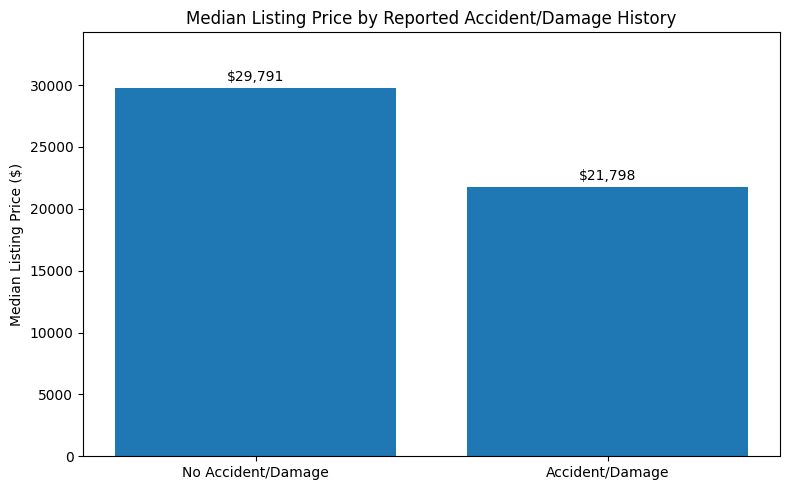

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
fig1_data = pd.Series({
    "No Accident/Damage": no_accident_median,
    "Accident/Damage": accident_median
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    fig1_data.index,
    fig1_data.values
)

plt.ylabel("Median Listing Price ($)")
plt.title("Median Listing Price by Reported Accident/Damage History")

for bar, value in zip(bars, fig1_data.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 500,
        f"${value:,.0f}",
        ha="center"
    )

plt.ylim(0, max(fig1_data.values) * 1.15)
plt.tight_layout()

filename = "01_raw_median_price_accident_history.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download(filename)

**Figure 1. Raw Median Listing Price by Accident/Damage History.** Among the April 2023 listings in the Hypothesis 1 sample, vehicles with reported accident or damage history had a median listing price of **$21,798**, compared with **$29,791** for vehicles without reported accident or damage history. This represents a raw difference of approximately **26.83%**, before accounting for differences in vehicle characteristics.

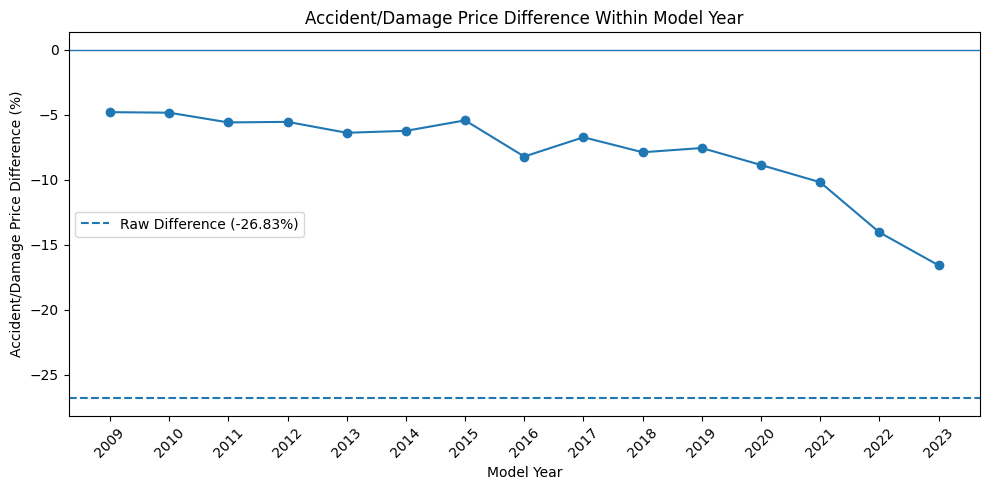

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(
    year_accident_medians.index,
    year_accident_medians["pct_difference"],
    marker="o"
)

plt.axhline(
    raw_accident_difference,
    linestyle="--",
    label=f"Raw Difference ({raw_accident_difference:.2f}%)"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Model Year")
plt.ylabel("Accident/Damage Price Difference (%)")
plt.title("Accident/Damage Price Difference Within Model Year")

plt.xticks(
    year_accident_medians.index,
    rotation=45
)

plt.legend()
plt.tight_layout()

filename = "02_accident_difference_by_model_year.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

files.download(filename)

**Figure 2. Accident/Damage Price Difference Within Model Year.** Comparing vehicles within the same model year substantially reduces the price difference observed in the raw data. For most model years from 2009 through 2020, vehicles with reported accident or damage history had median listing prices approximately **5% to 10% lower** than vehicles from the same model year without reported accident or damage history. This suggests that differences in vehicle age contributed substantially to the original raw price gap.

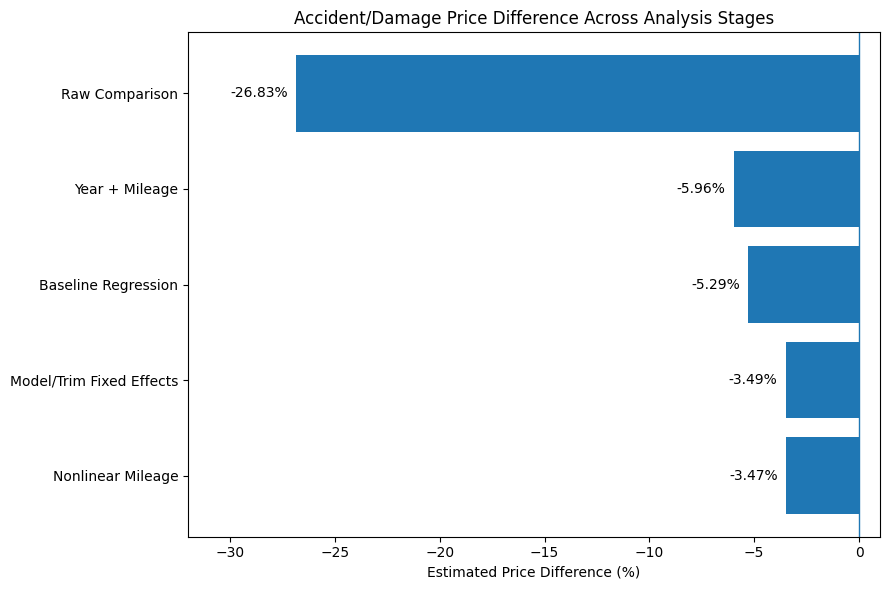

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
estimate_labels = [
    "Raw Comparison",
    "Year + Mileage",
    "Baseline Regression",
    "Model/Trim Fixed Effects",
    "Nonlinear Mileage"
]

estimate_values = [
    raw_accident_difference,
    weighted_average,
    accident_pct_1,
    accident_pct_2,
    accident_pct_final
]

plt.figure(figsize=(9, 6))

bars = plt.barh(
    estimate_labels,
    estimate_values
)

plt.axvline(0, linewidth=1)

plt.xlabel("Estimated Price Difference (%)")
plt.title("Accident/Damage Price Difference Across Analysis Stages")

# Put each percentage label just to the left of its bar
for bar, value in zip(bars, estimate_values):
    plt.text(
        value - 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="right"
    )

# Give the raw-comparison label enough room
plt.xlim(-32, 1)

plt.gca().invert_yaxis()
plt.tight_layout()

filename = "03_accident_estimate_progression.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

files.download(filename)

**Figure 3. Accident/Damage Price Difference Across Analysis Stages.** The raw median comparison showed a **26.83% lower** listing price among vehicles with reported accident or damage history. As differences in model year, mileage, manufacturer, model/trim, ownership and usage history, drivetrain, and fuel type were considered, the estimated difference became substantially smaller. The final model/trim fixed-effects specification with nonlinear mileage estimated an association of approximately **3.47% lower listing prices**.

## Hypothesis 1 Conclusion

My original hypothesis was that vehicles with reported accident or damage history would have lower listing prices than comparable vehicles without reported accident or damage history. I initially predicted that the difference would be approximately **10%**.

The analysis supported the direction of my hypothesis, but the final estimated difference was smaller than I originally expected. The raw data initially showed a **26.83% lower median listing price** among vehicles with reported accident or damage history. However, this comparison did not account for other differences between the vehicles.

As factors such as model year, mileage, manufacturer, model/trim, ownership and usage history, drivetrain, and fuel type were considered, the estimated difference became substantially smaller. In the final model/trim fixed-effects analysis with nonlinear mileage, reported accident or damage history was associated with approximately **3.47% lower listing prices**.

This showed me that accident history alone does not explain the difference in listing prices. My original prediction of approximately 10% was higher because I did not initially consider how much other characteristics, particularly model/trim, manufacturer, mileage, and model year, could affect a vehicle's price alongside its accident history.

From a business perspective, accident history should still be considered when evaluating or pricing a used vehicle, but it should not determine the evaluation by itself. Buyers, sellers, and dealerships should consider accident history alongside the other characteristics of the vehicle to develop a more complete understanding of its value.

These results represent associations within used-vehicle listings collected in **April 2023** and should not be interpreted as showing that an accident causes a vehicle's price to decrease by 3.47%.

## Hypothesis 2: Ownership History and Vehicle Price

I expect vehicles reported as one-owner vehicles to have higher listing prices than vehicles that are not reported as one-owner vehicles. Before analyzing the data, I predict that one-owner vehicles will have listing prices approximately **3% higher** after accounting for other vehicle characteristics.

My reasoning is that vehicles that have passed through multiple owners may be valued less in the used-car market. Ownership history may also be related to other characteristics such as vehicle age, since older vehicles have had more time to change owners.

Because the dataset only identifies whether a vehicle is reported as a one-owner vehicle, this analysis cannot determine the specific effect of having two, three, or more previous owners.

In [63]:
hypothesis2_vars = [
    "price",
    "one_owner",
    "accidents_or_damage",
    "manufacturer",
    "model",
    "year",
    "mileage",
    "personal_use_only",
    "drivetrain",
    "fuel_type"
]

h2 = cars_clean[hypothesis2_vars].dropna().copy()

print("Deduplicated price-cleaned dataset:", len(cars_clean))
print("H2 complete-data sample:", len(h2))
print(
    "Percent retained:",
    f"{len(h2) / len(cars_clean) * 100:.2f}%"
)

Deduplicated price-cleaned dataset: 752331
H2 complete-data sample: 694844
Percent retained: 92.36%


In [64]:
ownership_summary = (
    h2.groupby("one_owner")["price"]
      .agg(["count", "median", "mean"])
)

print(ownership_summary)

not_one_owner_median = h2.loc[
    h2["one_owner"] == 0, "price"
].median()

one_owner_median = h2.loc[
    h2["one_owner"] == 1, "price"
].median()

raw_owner_difference = (
    (one_owner_median / not_one_owner_median) - 1
) * 100

print(
    f"\nRaw median percentage difference: "
    f"{raw_owner_difference:.2f}%"
)

            count   median          mean
one_owner                               
0.0        308674  21995.0  26867.161047
1.0        386170  31879.5  35983.874532

Raw median percentage difference: 44.94%


In [65]:
ownership_characteristics = (
    h2.groupby("one_owner")
      .agg(
          observations=("price", "size"),
          median_year=("year", "median"),
          median_mileage=("mileage", "median"),
          median_price=("price", "median")
      )
)

ownership_characteristics

,observations,median_year,median_mileage,median_price
one_owner,,,,
0.0,308674,2017.0,68925.0,21995.0
1.0,386170,2020.0,33501.0,31879.5


### Initial Ownership-History Comparison

The raw comparison showed that vehicles reported as one-owner vehicles had a median listing price of **$31,879.50**, compared with **$21,995** for vehicles not reported as one-owner vehicles. This represents a raw difference of approximately **44.94%**, substantially larger than my initial prediction of approximately 3%.

However, the two groups also differed substantially in model year and mileage. One-owner vehicles had a median model year of **2020** and median mileage of **33,501 miles**, while vehicles not reported as one-owner had a median model year of **2017** and median mileage of **68,925 miles**.

This relates to my original expectation that ownership history may be connected to vehicle age. Older vehicles have had more time to change owners, while age and mileage can also reduce a vehicle's value independently of ownership history. Therefore, the raw 44.94% difference should not be attributed to ownership history alone.

### Controlled Ownership-History Analysis

The raw comparison showed a large difference in listing prices between one-owner and non-one-owner vehicles, but the two groups also differed substantially in model year and mileage.

To make a more comparable analysis, vehicles are compared within the same model/trim categories while accounting for model year, mileage, accident or damage history, personal-use history, drivetrain, and fuel type.

As in the accident-history analysis, model/trim categories must contain at least **25 one-owner listings and 25 non-one-owner listings** to be included. A nonlinear mileage term is also included because the relationship between mileage and vehicle value may not be constant across all mileage levels.

In [66]:
h2["log_price"] = np.log(h2["price"])

h2["drivetrain_clean"] = (
    h2["drivetrain"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map(drivetrain_map)
    .fillna("Other/Unspecified")
)

h2["fuel_clean"] = (
    h2["fuel_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(fuel_map)
    .fillna("Other")
)

h2["mileage_10k"] = h2["mileage"] / 10000
h2["mileage_10k_sq"] = h2["mileage_10k"] ** 2

In [67]:
model_owner_counts = (
    h2.groupby(["model", "one_owner"])
      .size()
      .unstack(fill_value=0)
)

eligible_owner_models = model_owner_counts[
    (model_owner_counts[0] >= 25) &
    (model_owner_counts[1] >= 25)
].index

h2_fe = h2[
    h2["model"].isin(eligible_owner_models)
].copy()

print(
    "Eligible model/trim categories:",
    len(eligible_owner_models)
)

print(
    "Observations in fixed-effects sample:",
    f"{len(h2_fe):,}"
)

print(
    "Percent of H2 sample retained:",
    f"{len(h2_fe) / len(h2) * 100:.2f}%"
)

print("\nOwnership counts:")
print(h2_fe["one_owner"].value_counts())

Eligible model/trim categories: 1403
Observations in fixed-effects sample: 568,649
Percent of H2 sample retained: 81.84%

Ownership counts:
one_owner
1.0    328521
0.0    240128
Name: count, dtype: int64


In [68]:
h2_fe_data = pd.DataFrame({
    "log_price": h2_fe["log_price"],
    "one_owner": h2_fe["one_owner"].astype(float),
    "mileage_10k": h2_fe["mileage_10k"],
    "mileage_10k_sq": h2_fe["mileage_10k_sq"],
    "accidents_or_damage":
        h2_fe["accidents_or_damage"].astype(float),
    "personal_use_only":
        h2_fe["personal_use_only"].astype(float)
})

h2_year_dummies = pd.get_dummies(
    h2_fe["year"],
    prefix="year",
    drop_first=True,
    dtype=float
)

h2_drive_dummies = pd.get_dummies(
    h2_fe["drivetrain_clean"],
    prefix="drive",
    drop_first=True,
    dtype=float
)

h2_fuel_dummies = pd.get_dummies(
    h2_fe["fuel_clean"],
    prefix="fuel",
    drop_first=True,
    dtype=float
)

h2_fe_data = pd.concat(
    [
        h2_fe_data,
        h2_year_dummies,
        h2_drive_dummies,
        h2_fuel_dummies
    ],
    axis=1
)

print("Observations:", f"{len(h2_fe_data):,}")
print("Regression variables:", h2_fe_data.shape[1])

Observations: 568,649
Regression variables: 63


In [69]:
h2_model_groups = h2_fe["model"]

h2_demeaned = (
    h2_fe_data -
    h2_fe_data.groupby(h2_model_groups).transform("mean")
)

print("Demeaned dataset shape:", h2_demeaned.shape)

Demeaned dataset shape: (568649, 63)


In [70]:
y_h2 = h2_demeaned["log_price"]

X_h2 = h2_demeaned.drop(
    columns="log_price"
)

model_h2 = sm.OLS(
    y_h2,
    X_h2
).fit()

owner_beta = model_h2.params["one_owner"]

owner_pct = (
    np.exp(owner_beta) - 1
) * 100

print(f"One-owner coefficient: {owner_beta:.4f}")
print(f"Estimated price difference: {owner_pct:.2f}%")
print(
    f"Within-model R-squared: "
    f"{model_h2.rsquared:.4f}"
)
print(
    f"Observations: "
    f"{int(model_h2.nobs):,}"
)

One-owner coefficient: 0.0048
Estimated price difference: 0.48%
Within-model R-squared: 0.8280
Observations: 568,649


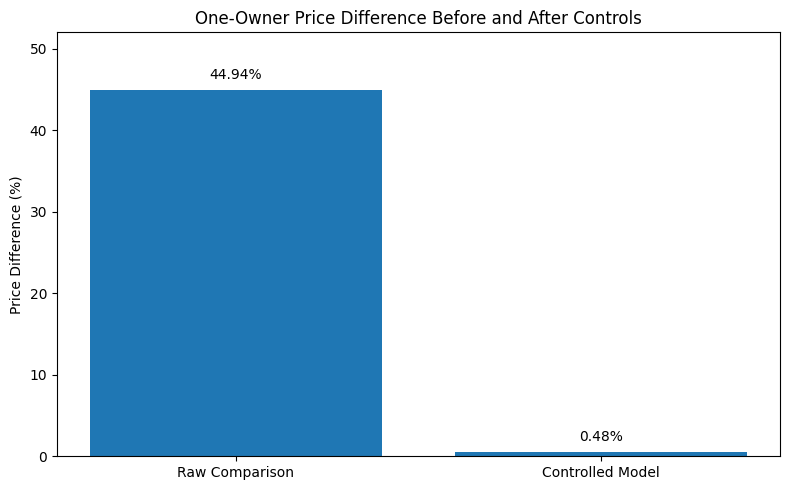

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
ownership_estimates = [
    raw_owner_difference,
    owner_pct
]

ownership_labels = [
    "Raw Comparison",
    "Controlled Model"
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    ownership_labels,
    ownership_estimates
)

plt.ylabel("Price Difference (%)")
plt.title("One-Owner Price Difference Before and After Controls")

for bar, value in zip(bars, ownership_estimates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 52)
plt.tight_layout()

filename = "04_one_owner_raw_vs_controlled.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

files.download(filename)

**Figure 4. One-Owner Price Difference Before and After Controls.** The raw comparison showed that vehicles reported as one-owner vehicles had median listing prices approximately **44.94% higher** than vehicles not reported as one-owner. However, one-owner vehicles were also newer and had substantially lower mileage. After accounting for model/trim, model year, mileage, accident history, personal-use history, drivetrain, and fuel type, reported one-owner status was associated with only approximately **0.49% higher listing prices**.

## Hypothesis 2 Conclusion

My original hypothesis was that vehicles reported as one-owner vehicles would have listing prices approximately **3% higher** than vehicles not reported as one-owner vehicles.

The raw comparison initially showed a much larger difference of **44.94%**. However, this comparison included other differences between the vehicles. One-owner vehicles were newer and had substantially lower mileage, and characteristics such as model/trim, mileage, model year, accident history, and other vehicle characteristics also influence listing prices.

After accounting for these differences, reported one-owner status was associated with only approximately **0.49% higher listing prices**. This was substantially smaller than both the raw 44.94% difference and my original prediction of approximately 3%.

This result changed how I think about ownership history as a factor in vehicle value. In this analysis, one-owner status had a relatively small association with listing price compared with the other characteristics considered in the model. Therefore, whether a vehicle is reported as one-owner should not be treated as a major factor by itself when evaluating a used vehicle.

From a business perspective, buyers, sellers, and dealerships should consider ownership history alongside factors such as model/trim, mileage, model year, accident history, and other vehicle characteristics rather than using one-owner status alone as a strong indicator of value.

As with the previous analysis, this result represents an association within the **April 2023 listing data** and should not be interpreted as showing that one-owner status causes a vehicle's price to increase by 0.49%.

## Limitations

Several limitations should be considered when interpreting this analysis.

First, the dataset contains U.S. used-vehicle listings collected in **April 2023**. The results therefore describe the listing market represented in that dataset and should not be interpreted as describing current used-car prices.

Second, the dataset reports **listing prices rather than final transaction prices**. The amount ultimately paid for a vehicle may differ from its advertised price.

Third, accident and damage history is recorded only as a binary variable. The dataset does not provide the **number or severity of accidents**, which prevents the analysis from determining whether minor damage and major accidents are associated with different changes in listing price. Similarly, ownership history is recorded only through whether a vehicle is reported as one-owner, rather than the exact number of previous owners.

The dataset also does not contain several characteristics that could influence vehicle value, including detailed service history, warranty information, detailed mechanical or cosmetic condition, and geographic location. Differences in these unobserved characteristics may contribute to the relationships observed in the analysis.

Listings missing variables required for each analysis were excluded rather than assigning unknown vehicle characteristics or histories. Because excluded listings may differ from the complete-data samples, this decision may affect how representative the final results are.

The fixed-effects analyses were also restricted to model/trim categories containing at least 25 observations from each group being compared. This improved the reliability of within-model comparisons but excluded less common model/trim categories.

Finally, this analysis uses observational data. The estimated price differences represent **associations and should not be interpreted as causal effects**.

## Final Business Takeaways

The main lesson from this analysis is that large differences in raw used-car prices can become substantially smaller once other vehicle characteristics are considered.

For accident history, the raw data showed that vehicles with reported accident or damage history had median listing prices approximately **26.83% lower**. After accounting for model/trim, model year, mileage, ownership and usage history, drivetrain, and fuel type, the final estimated difference was approximately **3.47% lower**.

The same pattern was even more noticeable for ownership history. One-owner vehicles initially had median listing prices approximately **44.94% higher**, but the controlled analysis found an association of only approximately **0.49% higher**.

These results changed how I think about evaluating used vehicles. A characteristic such as accident history or one-owner status may provide useful information, but looking at that characteristic alone can create a misleading picture of a vehicle's value. Model/trim, mileage, model year, and other characteristics also need to be considered when comparing vehicles.

For buyers, sellers, and dealerships, this means that vehicle pricing should be approached as a combination of characteristics rather than relying heavily on a single feature. It also demonstrates why raw comparisons should be examined carefully before being used to make business decisions.